In [1]:
# 기본 라이브러리 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 텐서플로우 사용 시 MS Visual C++ 빌드 도구 필요
# 링크: https://aka.ms/vs/17/release/vc_redist.x64.exe
# 딥러닝 관련 라이브러리 import
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Dropout

# 이미지를 인식하는 딥러닝 프로젝트 계획
# YOLO 모델 사용, 그 외 이미지 처리용 라이브러리 import
import cv2
from PIL import Image
from ultralytics import YOLO

# 데이터를 roboflow에서 가져오기 위한 라이브러리 import
import os
from roboflow import Roboflow

# roboflow 설정을 .env 파일로 관리하기 위한 라이브러리 import
from dotenv import load_dotenv

# .env 파일에서 Roboflow 설정을 불러오기
load_dotenv()
api_key = os.getenv("ROBOFLOW_API_KEY")
workspace_name = os.getenv("ROBOFLOW_WORKSPACE")
project_name = os.getenv("ROBOFLOW_PROJECT")
if not all((api_key, workspace_name, project_name)):
    raise RuntimeError(
        "ROBOFLOW_API_KEY, ROBOFLOW_WORKSPACE, and ROBOFLOW_PROJECT must be set in .env."
    )

# Roboflow 설정을 사용하여 프로젝트에 접근
rf = Roboflow(api_key=api_key)
project = rf.workspace(workspace_name).project(project_name)
version = project.version(1)
dataset = version.download("yolov8")

# 다운로드 경로 확인
yaml_path = dataset.location + "/data.yaml"
print(f"Dataset downloaded to: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...
Dataset downloaded to: e:\Human PRJ\DLPRJ\Sign-1


In [2]:
# 함수에 필요한 라이브러리를 추가 import
import yaml
import glob

# 로드한 데이터의 품질을 검증하는 함수
def verify_yolo_dataset(data_yaml_path):
    # 1. data.yaml 로드
    with open(data_yaml_path, 'r') as f:
        data_cfg = yaml.safe_load(f)
    
    root_path = data_cfg.get('path', os.path.dirname(data_yaml_path))
    num_classes = data_cfg['nc']
    class_names = data_cfg['names']
    
    print(f"=== 데이터셋 검증 시작 (총 클래스 수: {num_classes}) ===")
    
    splits = ['train', 'valid', 'val']
    class_counts = {i: 0 for i in range(num_classes)}
    
    for split in splits:
        img_dir = os.path.join(root_path, split, 'images')
        lbl_dir = os.path.join(root_path, split, 'labels')
        
        if not os.path.exists(img_dir):
            continue
            
        print(f"\n[{split.upper()} 세트 검사 중...]")
        
        # 이미지 및 라벨 탐색
        img_files = set(os.path.basename(f) for f in glob.glob(os.path.join(img_dir, '*.*')) 
                        if f.lower().endswith(('.jpg', '.png', '.jpeg')))
        lbl_files = set(os.path.basename(f) for f in glob.glob(os.path.join(lbl_dir, '*.txt')))
        
        corrupted_imgs = 0
        invalid_labels = 0
        missing_labels = 0
        
        for img_name in img_files:
            # 1. 이미지 손상 여부 검사
            img_path = os.path.join(img_dir, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify() # 이미지 무결성 체크
            except Exception:
                corrupted_imgs += 1
                continue
            
            # 2. 라벨 매칭 및 좌표 검사
            base_name = os.path.splitext(img_name)[0]
            lbl_name = f"{base_name}.txt"
            
            if lbl_name not in lbl_files:
                missing_labels += 1
                continue
                
            lbl_path = os.path.join(lbl_dir, lbl_name)
            with open(lbl_path, 'r') as f:
                lines = f.readlines()
                
            for line in lines:
                parts = line.strip().split()
                if len(parts) != 5:
                    invalid_labels += 1
                    continue
                
                cls_id, x, y, w, h = map(float, parts)
                cls_id = int(cls_id)
                
                # 라벨 값 및 좌표 범주 체크 (0~1 사이 정규화 여부)
                if cls_id >= num_classes or not (0 <= x <= 1 and 0 <= y <= 1 and 0 <= w <= 1 and 0 <= h <= 1):
                    invalid_labels += 1
                else:
                    class_counts[cls_id] += 1

        # 결과 요약 출력
        print(f" - 이미지 총 개수: {len(img_files)}개")
        print(f" - 손상된 이미지: {corrupted_imgs}개")
        print(f" - 누락된 라벨 파일: {missing_labels}개")
        print(f" - 잘못된 라벨 포맷/범위: {invalid_labels}개")
        
        if corrupted_imgs == 0 and missing_labels == 0 and invalid_labels == 0:
            print(f" => {split.upper()} 데이터셋 이상 없음 (PASSED)!")

    print("\n=== 클래스별 라벨 등장 횟수 (Top 5 / Bottom 5) ===")
    sorted_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
    print("가장 많은 클래스:", [(class_names[k], v) for k, v in sorted_counts[:5]])
    print("가장 적은 클래스:", [(class_names[k], v) for k, v in sorted_counts[-5:]])

# 검증 실행 (yaml_path는 데이터셋 다운로드 시 생성된 경로)
verify_yolo_dataset(yaml_path)

=== 데이터셋 검증 시작 (총 클래스 수: 59) ===

[TRAIN 세트 검사 중...]
 - 이미지 총 개수: 2124개
 - 손상된 이미지: 0개
 - 누락된 라벨 파일: 0개
 - 잘못된 라벨 포맷/범위: 0개
 => TRAIN 데이터셋 이상 없음 (PASSED)!

[VALID 세트 검사 중...]
 - 이미지 총 개수: 607개
 - 손상된 이미지: 0개
 - 누락된 라벨 파일: 0개
 - 잘못된 라벨 포맷/범위: 0개
 => VALID 데이터셋 이상 없음 (PASSED)!

=== 클래스별 라벨 등장 횟수 (Top 5 / Bottom 5) ===
가장 많은 클래스: [('NoStop', 142), ('TGT', 141), ('working', 129), ('50', 123), ('ByLeft', 117)]
가장 적은 클래스: [('NoCarAndMotor', 16), ('Electric', 15), ('NoHumanBike', 15), ('TriangleBlank', 11), ('BlackDot', 6)]


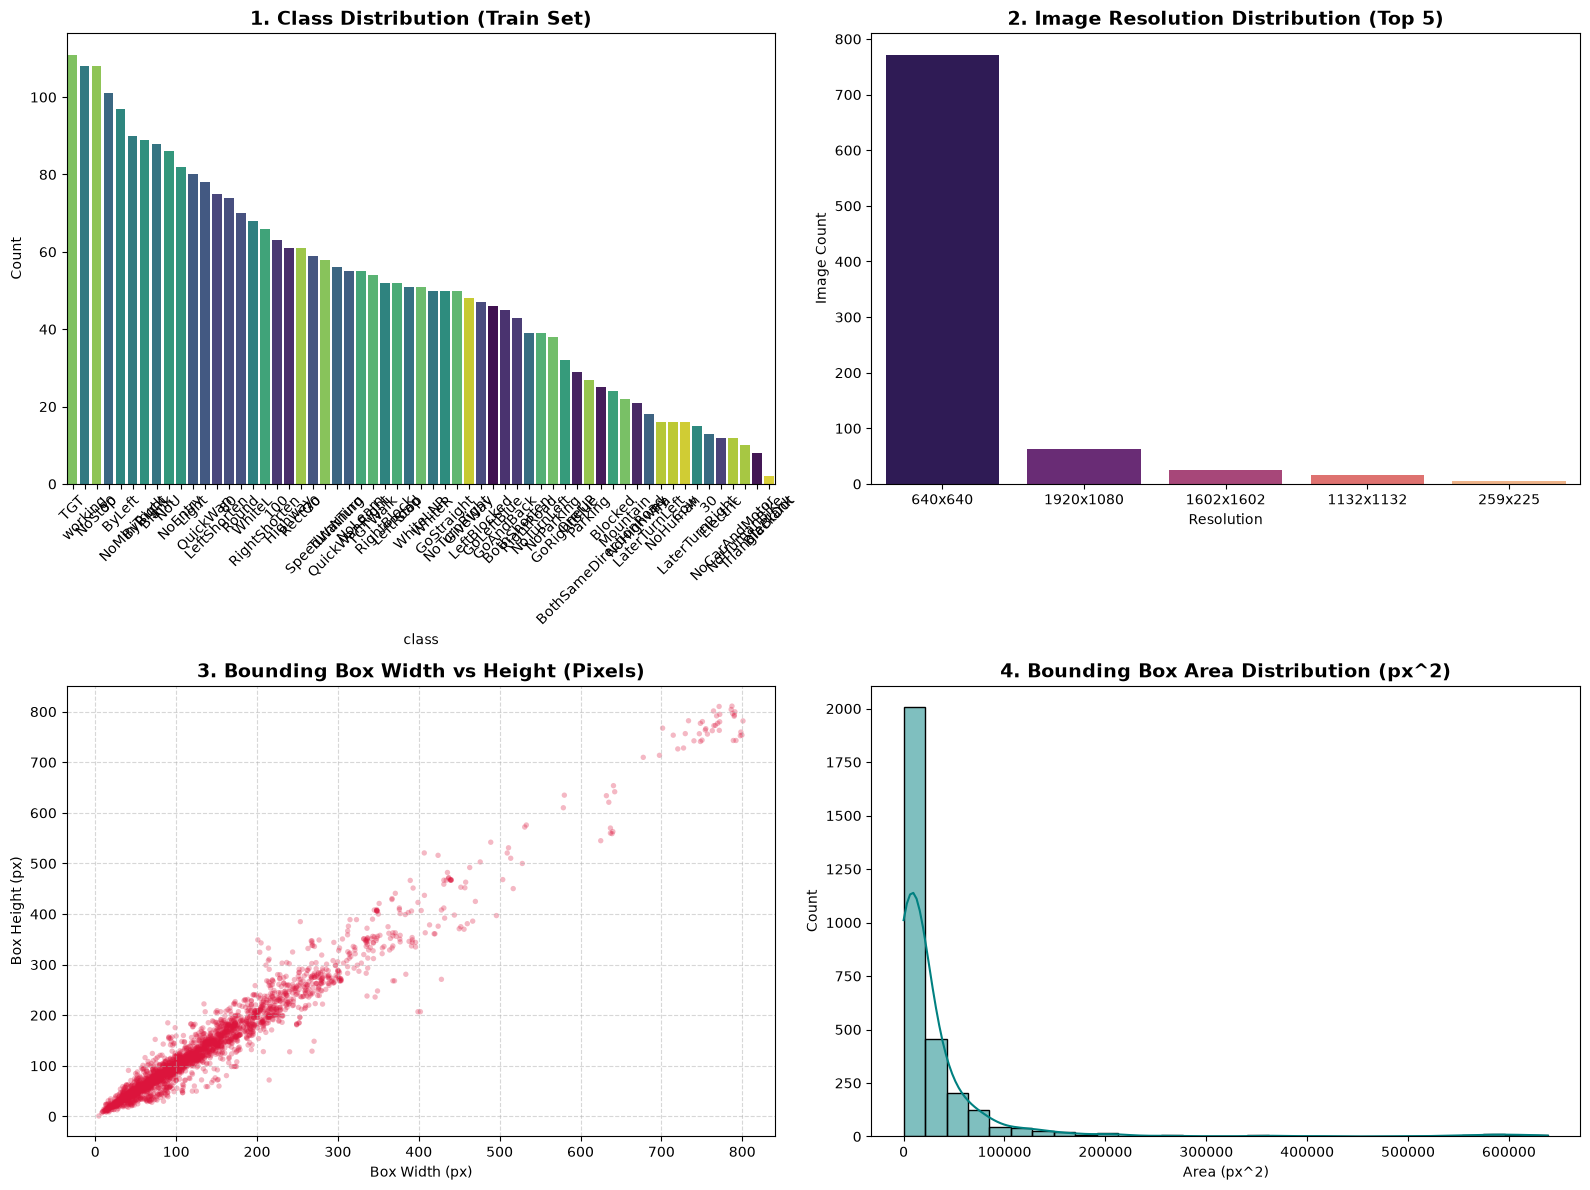

 총 분석된 이미지 수: 2124장
 총 바운딩 박스(글자/숫자) 수: 3012개
 가장 흔한 이미지 해상도: 640x640
 Bounding Box 평균 크기 (W x H): 136.2px x 135.5px


In [3]:
# 데이터셋 분포 종합 분석용 코드

def analyze_dataset_distributions(data_yaml_path):
    # 1. yaml 파일 로드
    with open(data_yaml_path, 'r') as f:
        data_cfg = yaml.safe_load(f)
        
    root_path = data_cfg.get('path', os.path.dirname(data_yaml_path))
    class_names = data_cfg['names']
    
    # 데이터 수집용 리스트
    class_list = []
    resolutions = []
    bbox_widths = []
    bbox_heights = []
    bbox_areas = []
    
    img_dir = os.path.join(root_path, 'train', 'images')
    lbl_dir = os.path.join(root_path, 'train', 'labels')
    
    img_files = glob.glob(os.path.join(img_dir, '*.*'))
    
    for img_path in img_files:
        try:
            with Image.open(img_path) as img:
                w_img, h_img = img.size
                resolutions.append((w_img, h_img))
        except Exception:
            continue
            
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = os.path.join(lbl_dir, f"{base_name}.txt")
        
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls_id, x, y, w, h = map(float, parts)
                        class_list.append(class_names[int(cls_id)])
                        bbox_widths.append(w * w_img)
                        bbox_heights.append(h * h_img)
                        bbox_areas.append((w * w_img) * (h * h_img))

    df_classes = pd.DataFrame({'class': class_list})
    df_res = pd.DataFrame(resolutions, columns=['Width', 'Height'])
    df_res['Resolution'] = df_res['Width'].astype(str) + 'x' + df_res['Height'].astype(str)
    
    # 시각화 (2x2 Grid)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1) 클래스 분포 (hue 할당 및 legend=False로 경고 해결)
    class_order = df_classes['class'].value_counts().index
    sns.countplot(
        data=df_classes, 
        x='class', 
        order=class_order, 
        hue='class', 
        legend=False, 
        ax=axes[0, 0], 
        palette='viridis'
    )
    axes[0, 0].set_title('1. Class Distribution (Train Set)', fontsize=14, fontweight='bold')
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].set_ylabel('Count')
    
    # 2) 해상도 분포 (hue 할당 및 legend=False로 경고 해결)
    top_res = df_res['Resolution'].value_counts().head(5).reset_index()
    top_res.columns = ['Resolution', 'Count']
    sns.barplot(
        data=top_res, 
        x='Resolution', 
        y='Count', 
        hue='Resolution', 
        legend=False, 
        ax=axes[0, 1], 
        palette='magma'
    )
    axes[0, 1].set_title('2. Image Resolution Distribution (Top 5)', fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel('Image Count')
    
    # 3) Bounding Box Width vs Height
    axes[1, 0].scatter(bbox_widths, bbox_heights, alpha=0.3, c='crimson', edgecolors='none', s=15)
    axes[1, 0].set_title('3. Bounding Box Width vs Height (Pixels)', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Box Width (px)')
    axes[1, 0].set_ylabel('Box Height (px)')
    axes[1, 0].grid(True, linestyle='--', alpha=0.5)
    
    # 4) Bounding Box 면적 히스토그램
    sns.histplot(bbox_areas, bins=30, kde=True, ax=axes[1, 1], color='teal')
    axes[1, 1].set_title('4. Bounding Box Area Distribution (px^2)', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Area (px^2)')

    plt.tight_layout()
    plt.show()
    
    print("=" * 60)
    print(f" 총 분석된 이미지 수: {len(img_files)}장")
    print(f" 총 바운딩 박스(글자/숫자) 수: {len(class_list)}개")
    print(f" 가장 흔한 이미지 해상도: {df_res['Resolution'].mode()[0]}")
    print(f" Bounding Box 평균 크기 (W x H): {np.mean(bbox_widths):.1f}px x {np.mean(bbox_heights):.1f}px")
    print("=" * 60)

# 실행
analyze_dataset_distributions(yaml_path)

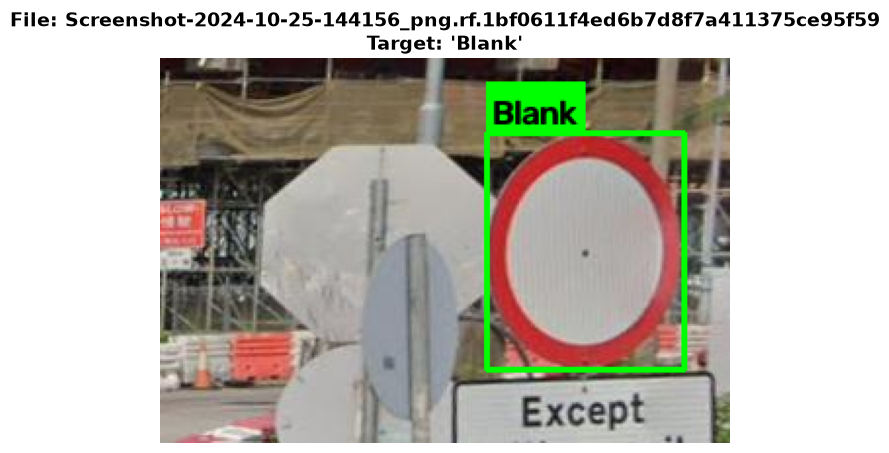

In [8]:
import random

# 학습용 이미지 확인용 코드
def visualize_random_sample(data_yaml_path):
    # 1. yaml 파일 로드
    with open(data_yaml_path, 'r') as f:
        data_cfg = yaml.safe_load(f)
        
    root_path = data_cfg.get('path', os.path.dirname(data_yaml_path))
    class_names = data_cfg['names']
    
    # 이미지 목록 가져오기
    img_dir = os.path.join(root_path, 'train', 'images')
    lbl_dir = os.path.join(root_path, 'train', 'labels')
    img_paths = glob.glob(os.path.join(img_dir, '*.*'))
    
    if not img_paths:
        print("이미지 파일을 찾을 수 없습니다.")
        return

    # 2. 랜덤 이미지 1장 선택
    random_img_path = random.choice(img_paths)
    base_name = os.path.splitext(os.path.basename(random_img_path))[0]
    lbl_path = os.path.join(lbl_dir, f"{base_name}.txt")
    
    # OpenCV로 이미지 읽기 (BGR -> RGB)
    img = cv2.imread(random_img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h_img, w_img, _ = img.shape
    
    # 3. 라벨 읽기 및 박스 그리기
    labels_found = []
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            lines = f.readlines()
            
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5:
                cls_id, x_c, y_c, w, h = map(float, parts)
                cls_name = class_names[int(cls_id)]
                labels_found.append((x_c, cls_name)) # X 좌표 정렬용
                
                # YOLO 정규화 좌표(0~1) -> 실제 픽셀 좌표 변환 (xmin, ymin, xmax, ymax)
                xmin = int((x_c - w / 2) * w_img)
                ymin = int((y_c - h / 2) * h_img)
                xmax = int((x_c + w / 2) * w_img)
                ymax = int((y_c + h / 2) * h_img)
                
                # 바운딩 박스 그리기 (녹색)
                color = (0, 255, 0)
                cv2.rectangle(img_rgb, (xmin, ymin), (xmax, ymax), color, 2)
                
                # 텍스트 및 배경 상자 크기 계산
                label_text = f"{cls_name}"
                (text_w, text_h), baseline = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
                
                # 텍스트 배경 상자 위치 계산
                bg_ymin = max(ymin - text_h - 10, 0)
                bg_ymax = ymin
                
                # 1) 텍스트 배경 상자 채우기 (테두리와 동일한 녹색)
                cv2.rectangle(img_rgb, (xmin, bg_ymin), (xmin + text_w + 6, bg_ymax), color, -1)
                
                # 2) 배경 위에 텍스트 쓰기
                cv2.putText(img_rgb, label_text, (xmin + 3, bg_ymax - 4),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

    # Bounding Box xmin 기준 오름차순 정렬하여 정답 문자열 생성
    labels_found.sort(key=lambda x: x[0])
    captcha_text = "".join([item[1] for item in labels_found])
    
    # 4. 시각화
    plt.figure(figsize=(8, 5))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"File: {base_name}\nTarget: '{captcha_text}'", fontsize=14, fontweight='bold')
    plt.show()

# 실행 (셀을 실행할 때마다 새로운 랜덤 이미지가 나옵니다)
visualize_random_sample(yaml_path)

In [7]:
# 데이터 분할
# roboflow에서 다운로드한 데이터셋은 이미 train, valid, test로 나뉘어져 있음
# 로컬 디렉토리에 다운로드 된 폴더 구조를 확인하면 train, valid, test 폴더가 존재함

# 데이터 정규화
# YOLO 모델 학습 시에는 이미지 정규화가 필요 없음 (YOLO 내부에서 처리됨)

# 데이터 증강
# 위 코드에서 검증한 결과 가장 많은 클래스는 140장 초과, 가장 적은 클래스는 10장 이하로 확인됨
# 따라서 데이터 증강을 통해 클래스 불균형 문제를 해결할 필요가 있음
# 우선 데이터 증강 적용 없이 학습해본 뒤, 결과와 성능을 확인하고 필요 시 증강 적용 여부를 결정

In [2]:
# GPU 환경에서 모델을 구동하기 위한 설정 및 점검
# 만약 PyTorch가 CPU 전용으로 설치되어 있다면 GPU를 인식하지 못함
# print("PyTorch Version:", torch.__version__) 실행 시 '+cpu'가 붙어있으면 CPU 전용 설치임
# GPU 사용을 위해서는 사용중인 GPU에 맞는 PyTorch CUDA 버전을 설치해야 함

# 필요 라이브러리 import
import torch
import os
from ultralytics import YOLO

# GPU 장치 연결 체크
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU 사용 가능: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("GPU를 찾을 수 없습니다. CPU로 학습이 진행되며, 학습 속도가 느릴 수 있습니다.")

GPU 사용 가능: NVIDIA GeForce RTX 4070 Ti SUPER


In [9]:
# 모델 설정
# GPU 환경을 사용하므로 학습에 여유가 있음
# Medium 모델을 사용할 예정
model = YOLO("yolov8m.pt")

# 현재 VGA에 적합한 학습 파라미터를 조사해서 적용
# 해당 파라미터는 모델의 mAP(인식 정확도) 향상을 목표로 하는것이 아닌,
# 하드웨어의 처리량을 고려해 조사된 값임
# 성능 향상 비교는 추후 데이터 증강 적용 전후를 비교한다
# 학습 파라미터 설정
results = model.train(
    data=yaml_path,         # 다운로드된 data.yaml 경로
    epochs=60,              # 캡차 데이터 기준 50~60 epoch
    imgsz=320,              # 캡차 해상도 최적화 (320x320)
    batch=64,               # VRAM 16GB 활용 대형 배치
    workers=8,              # i7 14700 CPU 멀티스레드 병렬 로딩
    device=device,          # 0번 GPU 사용
    amp=True,               # 16-bit 자동 혼합 정밀도 가속 (속도 향상 및 메모리 절약)
    project='captcha_yolo', # 결과 저장 루트 폴더
    name='v1_yolov8m',      # 실험 이름
    exist_ok=True,          # 동일 폴더 덮어쓰기 허용
    save=True               # best.pt 모델 가중치 저장
)

print("\n" + "=" * 60)
print("학습 완료! 저장된 최적 가중치 파일(best.pt) 경로:")
print(f" -> {os.path.abspath('captcha_yolo/v1_yolov8m/weights/best.pt')}")
print("=" * 60)

Ultralytics 8.4.132  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Ti SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=e:\Human PRJ\DLPRJ\Sign-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v1_yo

=== test 데이터셋 클래스별 평가 진행 중... ===
Ultralytics 8.4.132  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Ti SUPER, 16376MiB)
Model summary (fused): 93 layers, 25,873,921 parameters, 0 gradients, 78.9 GFLOPs
WARNING val: Slow image access detected (ping: 4.25.7 ms, read: 2.01.7 MB/s, size: 27.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning E:\Human PRJ\DLPRJ\Sign-1\test\labels.cache... 302 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 302/302  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 9.1it/s 2.1s<0.1s
                   all        302        401      0.757      0.848      0.833      0.765
Speed: 0.2ms preprocess, 3.3ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to E:\Human PRJ\DLPRJ\runs\detect\val-6

 [기존 모델 전체 요약 지표 (Test Set)]
 - Overall Precision : 0.7573
 

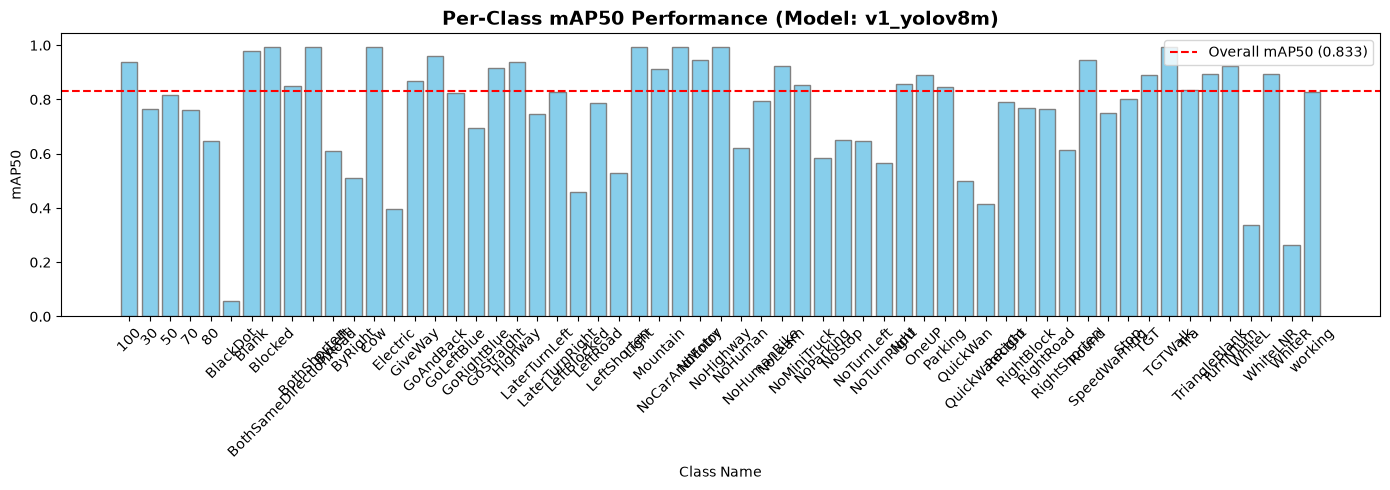

In [9]:
# 기본 모델에 대한 성능 평가
# 사전에 확인한 결과 클래스 데이터가 매우 불균형했음
# 클래스 불균형을 해소하기 전에, 실제로 불균형 해소가 필요한지 평가지표를 통해 검증
%matplotlib inline

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 기존 학습 완료된 모델 가중치 경로 설정
model_path = './runs/detect/captcha_yolo/v1_yolov8m/weights/best.pt'

# 모델 로드
model = YOLO(model_path)

# test 데이터셋 전체 평가 실행 (split='test')
print("=== test 데이터셋 클래스별 평가 진행 중... ===")
results = model.val(data=yaml_path, split='test', verbose=False)

# 클래스별 평가지표 데이터 프레임 구축
class_names = model.names  # {0: '0', 1: '1', ..., 35: 'Z'} 등

# 클래스별 AP50, Precision, Recall 추출
class_map50 = results.box.maps   # 각 클래스별 mAP50 배열
class_precision = results.box.p  # 각 클래스별 Precision 배열
class_recall = results.box.r     # 각 클래스별 Recall 배열

df_metrics = []
for idx, name in class_names.items():
    p = class_precision[idx] if idx < len(class_precision) else 0.0
    r = class_recall[idx] if idx < len(class_recall) else 0.0
    ap = class_map50[idx] if idx < len(class_map50) else 0.0
    
    df_metrics.append({
        'Class_ID': idx,
        'Class_Name': name,
        'Precision': round(float(p), 4),
        'Recall': round(float(r), 4),
        'mAP50': round(float(ap), 4)
    })

df_result = pd.DataFrame(df_metrics)

# 전체 요약 성능 출력
print("\n" + "="*50)
print(f" [기존 모델 전체 요약 지표 (Test Set)]")
print(f" - Overall Precision : {results.box.mp:.4f}")
print(f" - Overall Recall    : {results.box.mr:.4f}")
print(f" - Overall mAP50     : {results.box.map50:.4f}")
print("="*50)

# mAP50 기준 성능 하위 10개 클래스 (취약 클래스) 출력
print("\n [mAP50 기준 성능 취약 클래스 Top 10]")
print(df_result.sort_values(by='mAP50', ascending=True).head(10).to_string(index=False))

# 클래스별 mAP50 시각화 (성능 편차 및 파임 현상 확인)
plt.figure(figsize=(14, 5))
plt.bar(df_result['Class_Name'], df_result['mAP50'], color='skyblue', edgecolor='gray')
plt.axhline(results.box.map50, color='red', linestyle='--', label=f'Overall mAP50 ({results.box.map50:.3f})')
plt.title('Per-Class mAP50 Performance (Model: v1_yolov8m)', fontsize=14, fontweight='bold')
plt.xlabel('Class Name')
plt.ylabel('mAP50')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


 [취약 클래스 Top 10의 Train 데이터 수량 및 mAP50 비교]
 Class_ID    Class_Name  Train_Count  Recall  mAP50
        5      BlackDot            2  1.0000 0.0560
       57        WhiteR           50  1.0000 0.2633
       55        WhiteL           68  1.0000 0.3381
       13      Electric           12  1.0000 0.3980
       42 QuickWanRight           55  1.0000 0.4157
       22   LeftBlocked           47  0.8571 0.4601
       41      QuickWan           78  0.3333 0.4981
       11       ByRight           89  1.0000 0.5089
       24   LeftShorten           75  1.0000 0.5296
       37   NoTurnRight           50  0.7828 0.5659


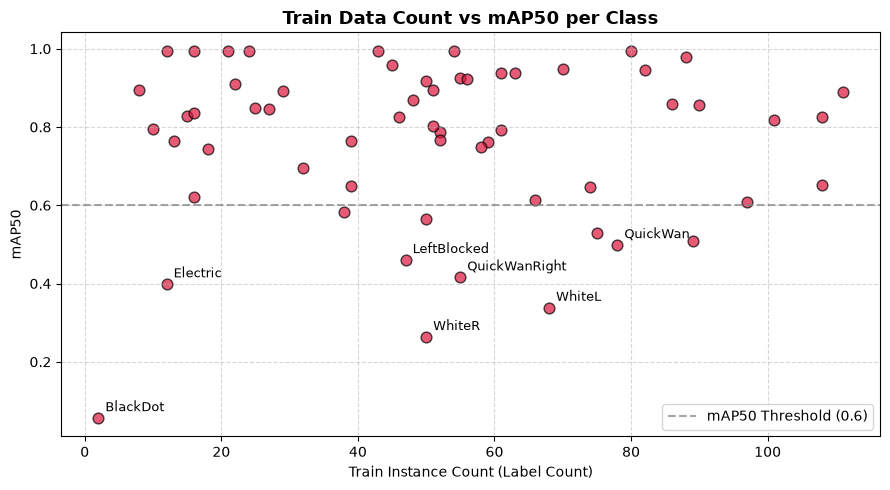

In [10]:
# 기존 평가 지표 검증 결과
# 재현율(Recall, 정답 중 모델이 맞춘 비율) 지표가 1.0이지만
# mAP50(mean Average Precision, 평균 정밀도) 지표가 매우 낮은 클래스가 존재함
# 조사 결과 클래스가 많고 배경이 복잡한 경우 mAP50 지표는 50~55% 이상을 긍정적으로 판단한다고 함
# 이는 모델이 검출 자체는 모두 성공하고 있지만, 바운딩 박스를 정밀하게 예측하지 못하고 있다는 의미
# 데이터의 바운딩 박스의 정밀도(IoU)가 낮거나 실제 정답 위치와 크게 틀어져 있을 가능성이 있음

# 데이터 개수가 충분한 상황이라면: 라벨링 노이즈, 객체 크기 혹은 IoU가 문제이므로 불균형 해소가 필요 없음
# 데이터 개수가 충분하지 않다면: 학습 미흡으로 인한 문제이므로 클래스 불균형 해소가 필요함

# 따라서 데이터셋의 클래스 개수를 집계해서 다시 확인 진행
%matplotlib inline

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# 1. train 라벨 폴더 경로 설정 (yaml_path 기준)
train_label_dir = os.path.join(os.path.dirname(yaml_path), 'train', 'labels')
label_files = glob.glob(os.path.join(train_label_dir, '*.txt'))

# 2. 클래스별 객체(Instance) 수량 집계
class_counts = {idx: 0 for idx in class_names.keys()}

for file_path in label_files:
    with open(file_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if parts:
                cls_id = int(parts[0])
                if cls_id in class_counts:
                    class_counts[cls_id] += 1

# 3. 기존 평가 지표(df_result)와 수량 데이터 결합
df_result['Train_Count'] = df_result['Class_ID'].map(class_counts)

# 4. mAP50 기준 하위 10개 취약 클래스의 [데이터 수량 + mAP50] 출력
print("\n" + "="*65)
print(" [취약 클래스 Top 10의 Train 데이터 수량 및 mAP50 비교]")
print("="*65)
print(df_result.sort_values(by='mAP50', ascending=True).head(10)[['Class_ID', 'Class_Name', 'Train_Count', 'Recall', 'mAP50']].to_string(index=False))

# 5. 상관관계 분석 (Train 수량 vs mAP50 산점도)
plt.figure(figsize=(9, 5))
plt.scatter(df_result['Train_Count'], df_result['mAP50'], color='crimson', alpha=0.7, edgecolors='k', s=60)
for _, row in df_result.iterrows():
    if row['mAP50'] < 0.5: # 취약 클래스 이름 표시
        plt.annotate(row['Class_Name'], (row['Train_Count'], row['mAP50']), fontsize=9, xytext=(5, 5), textcoords='offset points')

plt.title('Train Data Count vs mAP50 per Class', fontsize=13, fontweight='bold')
plt.xlabel('Train Instance Count (Label Count)')
plt.ylabel('mAP50')
plt.axhline(0.6, color='gray', linestyle='--', alpha=0.7, label='mAP50 Threshold (0.6)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# 데이터를 통해 소수 클래스에 대해 오버샘플링이 필요하다고 결론을 내림
# 소수 클래스들에게만 데이터 증강을 적용해서 새로 학습을 진행

import os
import torch
from ultralytics import YOLO

# GPU 장치 확인
device = 0 if torch.cuda.is_available() else 'cpu'

# Pretrained YOLOv8 Medium 모델 로드
model = YOLO("yolov8m.pt")

# [실험] 클래스 불균형 해소 적용 학습 실행
results = model.train(
    data=yaml_path,          # 다운로드된 data.yaml 경로
    epochs=60,               # 캡차 데이터 기준 50~60 epoch
    imgsz=320,               # 캡차 해상도 최적화 (320x320)
    batch=64,                # VRAM 16GB 활용 대형 배치
    workers=8,               # CPU 멀티스레드 병렬 로딩
    device=device,           # 0번 GPU 사용
    amp=True,                # 16-bit 자동 혼합 정밀도 가속
    project='captcha_yolo',  # 결과 저장 루트 폴더
    name='v2_v8m_balanced',  # 클래스 불균형 해소 실험 이름
    exist_ok=True,           # 동일 폴더 덮어쓰기 허용
    save=True,               # best.pt 모델 가중치 저장
    
    # 클래스 불균형 해소 및 소수 클래스 집중 학습 파라미터
    cls=2.0,                 # Class Loss 가중치 증대 (기본값 0.5 -> 2.0으로 상향하여 소수 클래스 분류 손실에 더 큰 패널티 부여)
    box=7.5,                 # Box Loss 가중치 (IoU 오차가 컸던 취약 클래스의 Bounding Box 정밀도 집중 학습)
    auto_augment='randaugment', # 소수 클래스 객체의 경계선 학습 강화를 위한 자동 증강 기법
    
    # 문자가 뒤집히면 라벨 의미가 변하므로 반전 차단
    fliplr=0.0,              # 좌우 반전 끄기
    flipud=0.0               # 상하 반전 끄기
)

print("\n" + "=" * 60)
print("학습 완료! 저장된 최적 가중치 파일(best.pt) 경로:")
print(f" -> {os.path.abspath('captcha_yolo/v2_v8m_balanced/weights/best.pt')}")
print("=" * 60)

New https://pypi.org/project/ultralytics/8.4.135 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.132  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Ti SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=2.0, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=e:\Human PRJ\DLPRJ\Sign-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det

=== [v2_v8m_balanced] test 데이터셋 클래스별 평가 진행 중... ===
Ultralytics 8.4.132  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Ti SUPER, 16376MiB)
Model summary (fused): 93 layers, 25,873,921 parameters, 0 gradients, 78.9 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 978.7672.9 MB/s, size: 92.1 KB)
val: Scanning E:\Human PRJ\DLPRJ\Sign-1\test\labels.cache... 302 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 302/302  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 15.2it/s 1.2s0.1s
                   all        302        401      0.947      0.912      0.975      0.892
Speed: 0.2ms preprocess, 2.1ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to E:\Human PRJ\DLPRJ\runs\detect\val-3

 [v2_v8m_balanced 전체 요약 지표 (Test Set)]
 - Overall Precision : 0.9474
 - Overall Recall    : 0.9122
 - Overall mAP50     : 0.9750

 [v2_v8m_balanced - mAP50 기준 취약 클래스 Top 10]
 Class_ID Class_N

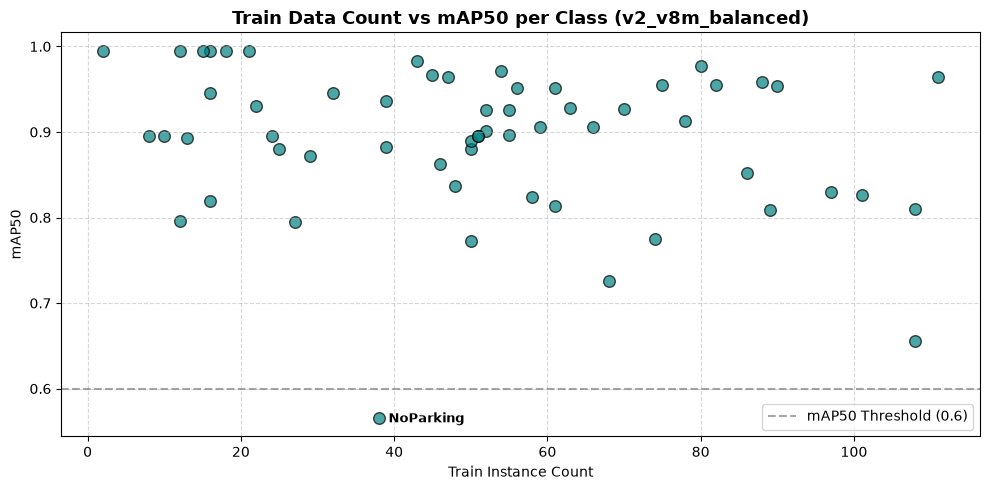

In [10]:
# 새로 학습된 모델에 대한 성능 평가

%matplotlib inline
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. v2_v8m_balanced 모델 가중치 로드
model_path_v2 = './runs/detect/captcha_yolo/v2_v8m_balanced/weights/best.pt'
model_v2 = YOLO(model_path_v2)

# 2. test 데이터셋 전체 평가 실행 (split='test')
print("=== [v2_v8m_balanced] test 데이터셋 클래스별 평가 진행 중... ===")
results_v2 = model_v2.val(data=yaml_path, split='test', verbose=False)

# 3. 클래스별 평가지표 추출
class_names = model_v2.names
class_map50 = results_v2.box.maps
class_precision = results_v2.box.p
class_recall = results_v2.box.r

# 4. Train 데이터셋 객체(Instance) 수량 재집계 (기존 방식 유지)
train_label_dir = os.path.join(os.path.dirname(yaml_path), 'train', 'labels')
label_files = glob.glob(os.path.join(train_label_dir, '*.txt'))

class_counts = {idx: 0 for idx in class_names.keys()}
for file_path in label_files:
    with open(file_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if parts:
                cls_id = int(parts[0])
                if cls_id in class_counts:
                    class_counts[cls_id] += 1

# 5. 데이터프레임 구축
df_metrics_v2 = []
for idx, name in class_names.items():
    p = class_precision[idx] if idx < len(class_precision) else 0.0
    r = class_recall[idx] if idx < len(class_recall) else 0.0
    ap = class_map50[idx] if idx < len(class_map50) else 0.0
    
    df_metrics_v2.append({
        'Class_ID': idx,
        'Class_Name': name,
        'Train_Count': class_counts.get(idx, 0),
        'Precision': round(float(p), 4),
        'Recall': round(float(r), 4),
        'mAP50': round(float(ap), 4)
    })

df_result_v2 = pd.DataFrame(df_metrics_v2)

# 6. 전체 요약 성능 출력
print("\n" + "="*50)
print(f" [v2_v8m_balanced 전체 요약 지표 (Test Set)]")
print(f" - Overall Precision : {results_v2.box.mp:.4f}")
print(f" - Overall Recall    : {results_v2.box.mr:.4f}")
print(f" - Overall mAP50     : {results_v2.box.map50:.4f}")
print("="*50)

# 7. mAP50 기준 성능 취약 클래스 Top 10 출력
print("\n [v2_v8m_balanced - mAP50 기준 취약 클래스 Top 10]")
print(df_result_v2.sort_values(by='mAP50', ascending=True).head(10)[['Class_ID', 'Class_Name', 'Train_Count', 'Precision', 'Recall', 'mAP50']].to_string(index=False))

# 8. Train_Count vs mAP50 산점도 시각화
plt.figure(figsize=(10, 5))
plt.scatter(df_result_v2['Train_Count'], df_result_v2['mAP50'], color='teal', alpha=0.7, edgecolors='k', s=70)

for _, row in df_result_v2.iterrows():
    if row['mAP50'] < 0.6:
        plt.annotate(
            row['Class_Name'], 
            (row['Train_Count'], row['mAP50']), 
            fontsize=9, 
            xytext=(7, -3), 
            textcoords='offset points',
            fontweight='bold'
        )

plt.title('Train Data Count vs mAP50 per Class (v2_v8m_balanced)', fontsize=13, fontweight='bold')
plt.xlabel('Train Instance Count')
plt.ylabel('mAP50')
plt.axhline(0.6, color='gray', linestyle='--', alpha=0.7, label='mAP50 Threshold (0.6)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# 데이터 증강을 통해 클래스 불균형 문제가 해결됨을 확인
# 이번에는 연산 비용 효율성 향상 검증을 목적으로 nano 모델을 사용할 예정
# nano 모델 또한 클래스 불균형 해소 이전과 이후를 모두 검증

# nano 모델 + 클래스 불균형 미해소 모델 코드
import os
import torch
from ultralytics import YOLO

# 1. GPU 장치 확인
device = 0 if torch.cuda.is_available() else 'cpu'

# 2. Pretrained YOLOv8 Nano 모델 로드
model = YOLO("yolov8n.pt")

# 3. YOLOv8n (Nano) 기본 학습 (불균형 해소 전)
results = model.train(
    data=yaml_path,          # 다운로드된 data.yaml 경로
    epochs=60,               # 60 epoch
    imgsz=320,               # 캡차 해상도 최적화 (320x320)
    batch=64,                # 대형 배치
    workers=8,               # CPU 멀티스레드
    device=device,           # 0번 GPU 사용
    amp=True,                # 16-bit 자동 혼합 정밀도 가속
    project='captcha_yolo',  # 결과 저장 루트 폴더
    name='v1_yolov8n',       # Nano 기본 모델 (불균형 해소 전)
    exist_ok=True,           # 동일 폴더 덮어쓰기 허용
    save=True,               # best.pt 모델 가중치 저장
)

print("\n" + "=" * 60)
print("학습 완료! 저장된 최적 가중치 파일(best.pt) 경로:")
print(f" -> {os.path.abspath('captcha_yolo/v1_yolov8n/weights/best.pt')}")
print("=" * 60)

New https://pypi.org/project/ultralytics/8.4.135 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.132  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Ti SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=e:\Human PRJ\DLPRJ\Sign-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det

=== [v1_yolov8n] test 데이터셋 클래스별 평가 진행 중... ===
Ultralytics 8.4.132  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Ti SUPER, 16376MiB)
Model summary (fused): 73 layers, 3,017,153 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 952.5739.9 MB/s, size: 92.1 KB)
val: Scanning E:\Human PRJ\DLPRJ\Sign-1\test\labels.cache... 302 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 302/302  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 14.1it/s 1.3s0.1s
                   all        302        401      0.788      0.818      0.838      0.759
Speed: 0.3ms preprocess, 1.8ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to E:\Human PRJ\DLPRJ\runs\detect\val-4

 [v1_yolov8n 전체 요약 지표 (Test Set)]
 - Overall Precision : 0.7884
 - Overall Recall    : 0.8176
 - Overall mAP50     : 0.8379

 [v1_yolov8n - mAP50 기준 취약 클래스 Top 10]
 Class_ID    Class_Name  Train_Cou

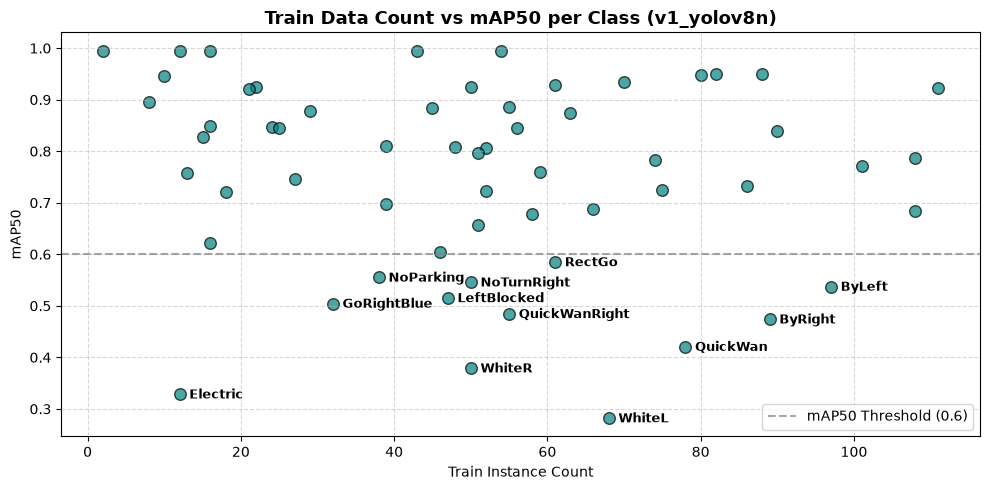

In [12]:
# 나노 + 불균형 미해소 모델에 대한 성능 평가

%matplotlib inline
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. v1_yolov8n 모델 가중치 로드
model_path_v3 = './runs/detect/captcha_yolo/v1_yolov8n/weights/best.pt'
model_v3 = YOLO(model_path_v3)

# 2. test 데이터셋 전체 평가 실행 (split='test')
print("=== [v1_yolov8n] test 데이터셋 클래스별 평가 진행 중... ===")
results_v3 = model_v3.val(data=yaml_path, split='test', verbose=False)

# 3. 클래스별 평가지표 추출
class_names = model_v3.names
class_map50 = results_v3.box.maps
class_precision = results_v3.box.p
class_recall = results_v3.box.r

# 4. Train 데이터셋 객체(Instance) 수량 재집계 (기존 방식 유지)
train_label_dir = os.path.join(os.path.dirname(yaml_path), 'train', 'labels')
label_files = glob.glob(os.path.join(train_label_dir, '*.txt'))

class_counts = {idx: 0 for idx in class_names.keys()}
for file_path in label_files:
    with open(file_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if parts:
                cls_id = int(parts[0])
                if cls_id in class_counts:
                    class_counts[cls_id] += 1

# 5. 데이터프레임 구축
df_metrics_v3 = []
for idx, name in class_names.items():
    p = class_precision[idx] if idx < len(class_precision) else 0.0
    r = class_recall[idx] if idx < len(class_recall) else 0.0
    ap = class_map50[idx] if idx < len(class_map50) else 0.0
    
    df_metrics_v3.append({
        'Class_ID': idx,
        'Class_Name': name,
        'Train_Count': class_counts.get(idx, 0),
        'Precision': round(float(p), 4),
        'Recall': round(float(r), 4),
        'mAP50': round(float(ap), 4)
    })

df_result_v3 = pd.DataFrame(df_metrics_v3)

# 6. 전체 요약 성능 출력
print("\n" + "="*50)
print(f" [v1_yolov8n 전체 요약 지표 (Test Set)]")
print(f" - Overall Precision : {results_v3.box.mp:.4f}")
print(f" - Overall Recall    : {results_v3.box.mr:.4f}")
print(f" - Overall mAP50     : {results_v3.box.map50:.4f}")
print("="*50)

# 7. mAP50 기준 성능 취약 클래스 Top 10 출력
print("\n [v1_yolov8n - mAP50 기준 취약 클래스 Top 10]")
print(df_result_v3.sort_values(by='mAP50', ascending=True).head(10)[['Class_ID', 'Class_Name', 'Train_Count', 'Precision', 'Recall', 'mAP50']].to_string(index=False))

# 8. Train_Count vs mAP50 산점도 시각화
plt.figure(figsize=(10, 5))
plt.scatter(df_result_v3['Train_Count'], df_result_v3['mAP50'], color='teal', alpha=0.7, edgecolors='k', s=70)

for _, row in df_result_v3.iterrows():
    if row['mAP50'] < 0.6:
        plt.annotate(
            row['Class_Name'], 
            (row['Train_Count'], row['mAP50']), 
            fontsize=9, 
            xytext=(7, -3), 
            textcoords='offset points',
            fontweight='bold'
        )

plt.title('Train Data Count vs mAP50 per Class (v1_yolov8n)', fontsize=13, fontweight='bold')
plt.xlabel('Train Instance Count')
plt.ylabel('mAP50')
plt.axhline(0.6, color='gray', linestyle='--', alpha=0.7, label='mAP50 Threshold (0.6)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [13]:
import os
import torch
from ultralytics import YOLO

# GPU 장치 확인
device = 0 if torch.cuda.is_available() else 'cpu'

# Pretrained YOLOv8 Nano 모델 로드
model = YOLO("yolov8n.pt")

# YOLOv8n (Nano) + 불균형 해소 적용 학습
results = model.train(
    data=yaml_path,          # 다운로드된 data.yaml 경로
    epochs=60,               # 60 epoch
    imgsz=320,               # 캡차 해상도 최적화 (320x320)
    batch=64,                # 대형 배치
    workers=8,               # CPU 멀티스레드
    device=device,           # 0번 GPU 사용
    amp=True,                # 16-bit 자동 혼합 정밀도 가속
    project='captcha_yolo',  # 결과 저장 루트 폴더
    name='v2_v8n_balanced',  # Nano 불균형 해소 적용 모델
    exist_ok=True,           # 동일 폴더 덮어쓰기 허용
    save=True,               # best.pt 모델 가중치 저장
    
    # 클래스 불균형 해소 파라미터
    cls=2.0,                 # Class Loss 가중치 증대
    box=7.5,                 # Box Loss 가중치 증대
    
    # 반전 차단
    fliplr=0.0,              # 좌우 반전 끄기
    flipud=0.0               # 상하 반전 끄기
)

print("\n" + "=" * 60)
print("[실험 3-2] 학습 완료! 저장된 최적 가중치 파일(best.pt) 경로:")
print(f" -> {os.path.abspath('captcha_yolo/v2_v8n_balanced/weights/best.pt')}")
print("=" * 60)

New https://pypi.org/project/ultralytics/8.4.135 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.132  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Ti SUPER, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=2.0, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=e:\Human PRJ\DLPRJ\Sign-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det

=== [v2_v8n_balanced] test 데이터셋 클래스별 평가 진행 중... ===
Ultralytics 8.4.132  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Ti SUPER, 16376MiB)
Model summary (fused): 73 layers, 3,017,153 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 763.8830.4 MB/s, size: 92.1 KB)
val: Scanning E:\Human PRJ\DLPRJ\Sign-1\test\labels.cache... 302 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 302/302  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 18.8it/s 1.0s0.1s
                   all        302        401      0.925      0.871      0.943      0.841
Speed: 0.2ms preprocess, 1.0ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to E:\Human PRJ\DLPRJ\runs\detect\val-5

 [v2_v8n_balanced 전체 요약 지표 (Test Set)]
 - Overall Precision : 0.9252
 - Overall Recall    : 0.8714
 - Overall mAP50     : 0.9430

 [v2_v8n_balanced - mAP50 기준 취약 클래스 Top 10]
 Class_ID    Class_

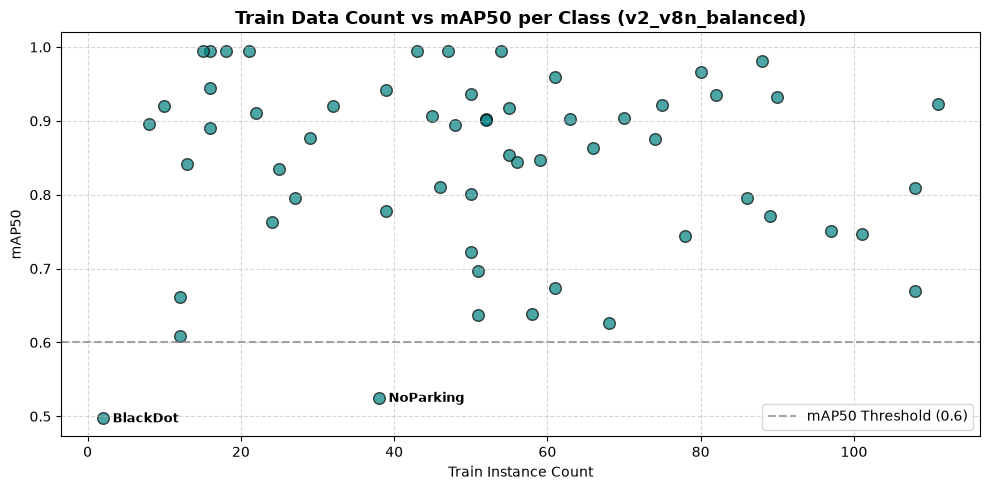

In [14]:
# 나노 + 불균형 해소 모델에 대한 평가

%matplotlib inline
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. v2_v8n_balanced 모델 가중치 로드
model_path_v4 = './runs/detect/captcha_yolo/v2_v8n_balanced/weights/best.pt'
model_v4 = YOLO(model_path_v4)

# 2. test 데이터셋 전체 평가 실행 (split='test')
print("=== [v2_v8n_balanced] test 데이터셋 클래스별 평가 진행 중... ===")
results_v4 = model_v4.val(data=yaml_path, split='test', verbose=False)

# 3. 클래스별 평가지표 추출
class_names = model_v4.names
class_map50 = results_v4.box.maps
class_precision = results_v4.box.p
class_recall = results_v4.box.r

# 4. Train 데이터셋 객체(Instance) 수량 재집계 (기존 방식 유지)
train_label_dir = os.path.join(os.path.dirname(yaml_path), 'train', 'labels')
label_files = glob.glob(os.path.join(train_label_dir, '*.txt'))

class_counts = {idx: 0 for idx in class_names.keys()}
for file_path in label_files:
    with open(file_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if parts:
                cls_id = int(parts[0])
                if cls_id in class_counts:
                    class_counts[cls_id] += 1

# 5. 데이터프레임 구축
df_metrics_v4 = []
for idx, name in class_names.items():
    p = class_precision[idx] if idx < len(class_precision) else 0.0
    r = class_recall[idx] if idx < len(class_recall) else 0.0
    ap = class_map50[idx] if idx < len(class_map50) else 0.0
    
    df_metrics_v4.append({
        'Class_ID': idx,
        'Class_Name': name,
        'Train_Count': class_counts.get(idx, 0),
        'Precision': round(float(p), 4),
        'Recall': round(float(r), 4),
        'mAP50': round(float(ap), 4)
    })

df_result_v4 = pd.DataFrame(df_metrics_v4)

# 6. 전체 요약 성능 출력
print("\n" + "="*50)
print(f" [v2_v8n_balanced 전체 요약 지표 (Test Set)]")
print(f" - Overall Precision : {results_v4.box.mp:.4f}")
print(f" - Overall Recall    : {results_v4.box.mr:.4f}")
print(f" - Overall mAP50     : {results_v4.box.map50:.4f}")
print("="*50)

# 7. mAP50 기준 성능 취약 클래스 Top 10 출력
print("\n [v2_v8n_balanced - mAP50 기준 취약 클래스 Top 10]")
print(df_result_v4.sort_values(by='mAP50', ascending=True).head(10)[['Class_ID', 'Class_Name', 'Train_Count', 'Precision', 'Recall', 'mAP50']].to_string(index=False))

# 8. Train_Count vs mAP50 산점도 시각화
plt.figure(figsize=(10, 5))
plt.scatter(df_result_v4['Train_Count'], df_result_v4['mAP50'], color='teal', alpha=0.7, edgecolors='k', s=70)

for _, row in df_result_v4.iterrows():
    if row['mAP50'] < 0.6:
        plt.annotate(
            row['Class_Name'], 
            (row['Train_Count'], row['mAP50']), 
            fontsize=9, 
            xytext=(7, -3), 
            textcoords='offset points',
            fontweight='bold'
        )

plt.title('Train Data Count vs mAP50 per Class (v2_v8n_balanced)', fontsize=13, fontweight='bold')
plt.xlabel('Train Instance Count')
plt.ylabel('mAP50')
plt.axhline(0.6, color='gray', linestyle='--', alpha=0.7, label='mAP50 Threshold (0.6)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [ ]:
# 진행 중지

# 하단 내용 이미 진행됐으므로 추후 편집 예정
# 또한 맨처음 학습한 모델에 대해서도 이 시각화 다시 적용해야함
# (기존것은 단독시각화에 사용예정)

# YOLOv8 프레임워크는 모델 구조를 정의하고 직접 컴파일하던 방식과 달리,
# model.train() 사용 시 내부적으로 모델 구조를 정의하고 학습, 손실 함수 및 옵티마이저 등을 자동 매핑함
# 따라서 성능 향상 혹은 계산 비용 효율성 향상을 위해서는 데이터 증강, 경량 모델 사용을 비교할 예정
# 1. YOLOv8 medium & 데이터 증강X = 학습 완료
# 2. YOLOv8 medium & 데이터 증강O
# 3. YOLOv8 nano & 데이터 증강X
# 4. YOLOv8 nano & 데이터 증강O

# 학습 완료된 모델(.pt)을 사용해 예측 수행

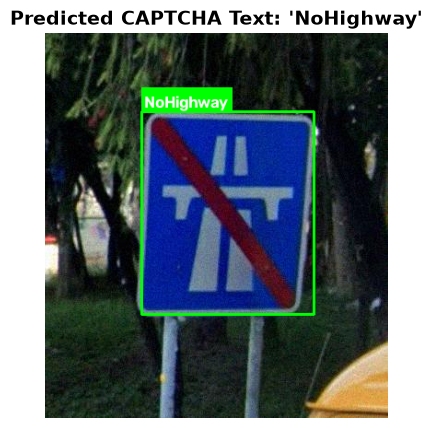

In [ ]:
# <!-- 코드 수정 예정 -->

import os
import glob
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import random

test_img_dir = os.path.join(os.path.dirname(yaml_path), 'test', 'images')
test_imgs = glob.glob(os.path.join(test_img_dir, '*.*'))

# 학습 완료된 최적 가중치(.pt 파일) 로드
# 비교할 모델이 총 4개(예정)이므로, 코드상 경로 갱신이 필요함
# 모델 학습 및 지표 평가 후 최종 갱신 예정
best_model_path = 'runs/detect/captcha_yolo/v1_yolov8m/weights/best.pt' # <- 수정 예정
model = YOLO(best_model_path)

def predict_captcha(image_path, conf_threshold=0.25):
    # YOLO 추론 실행
    results = model.predict(source=image_path, conf=conf_threshold, verbose=False)[0]
    
    boxes_info = []
    
    # 감지된 Bounding Box 정보 추출
    for box in results.boxes:
        xyxy = box.xyxy[0].cpu().numpy()  # [xmin, ymin, xmax, ymax]
        cls_id = int(box.cls[0].cpu().numpy())
        cls_name = model.names[cls_id]
        
        xmin = xyxy[0]
        boxes_info.append((xmin, cls_name, xyxy))
    
    # 2. X축(xmin) 기준 오름차순 정렬 (좌 -> 우 순서 정렬)
    boxes_info.sort(key=lambda x: x[0])
    
    # 3. 정렬된 클래스 이름 합쳐서 최종 캡차 텍스트 생성
    predicted_text = "".join([item[1] for item in boxes_info])
    
    # 4. 시각화 처리
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    for _, cls_name, xyxy in boxes_info:
        xmin, ymin, xmax, ymax = map(int, xyxy)
        color = (0, 255, 0) # 녹색 테두리
        
        cv2.rectangle(img_rgb, (xmin, ymin), (xmax, ymax), color, 2)
        
        # 텍스트 및 배경 박스
        (text_w, text_h), _ = cv2.getTextSize(cls_name, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        bg_ymin = max(ymin - text_h - 10, 0)
        cv2.rectangle(img_rgb, (xmin, bg_ymin), (xmin + text_w + 6, ymin), color, -1)
        cv2.putText(img_rgb, cls_name, (xmin + 3, ymin - 4), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        
    return predicted_text, img_rgb

# Test 세트에서 이미지 1장으로 테스트 실행
test_img_dir = os.path.join(os.path.dirname(yaml_path), 'test', 'images')
test_imgs = glob.glob(os.path.join(test_img_dir, '*.*'))

if test_imgs:
    # sample_img_path = test_imgs[0]
    sample_img_path = random.choice(test_imgs)
    
    pred_text, vis_img = predict_captcha(sample_img_path)
    
    plt.figure(figsize=(8, 5))
    plt.imshow(vis_img)
    plt.axis('off')
    plt.title(f"Predicted CAPTCHA Text: '{pred_text}'", fontsize=14, fontweight='bold')
    plt.show()
else:
    print("test/images 폴더에서 이미지를 찾을 수 없습니다.")